# 🤖 InsuraSight — Notebook 02 : Modélisation Actuarielle

Double modélisation fréquence × sévérité, standard en assurance IARD.

**Plan :**
1. Chargement et split train/test
2. Modèle fréquence : GLM Poisson vs XGBoost Poisson
3. Modèle sévérité : GLM Gamma vs XGBoost Gamma
4. Prime pure = E[N] × E[C|N>0]
5. Explicabilité SHAP
6. Comparaison et choix du modèle champion

> **Pré-requis** : exécuter `src/features/build_features.py` pour générer `data/features/table_modelisation.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle, os, warnings

import mlflow
import mlflow.sklearn
import mlflow.xgboost

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import mean_absolute_error, mean_squared_error, mean_poisson_deviance
from sklearn.linear_model    import PoissonRegressor, GammaRegressor
from sklearn.pipeline        import Pipeline
import xgboost as xgb
import shap

warnings.filterwarnings("ignore")
os.makedirs("models", exist_ok=True)
os.makedirs("reports/figures", exist_ok=True)

SEED = 42
np.random.seed(SEED)

COLORS = {"primary":"#1B4F72","secondary":"#2E86C1","accent":"#E74C3C",
          "success":"#27AE60","warn":"#F39C12","neutral":"#5D6D7E"}
plt.rcParams.update({"figure.dpi":120,"figure.facecolor":"white",
                     "axes.spines.top":False,"axes.spines.right":False})
print("✅ Imports OK")

✅ Imports OK


## 1. Chargement et split train/test

In [2]:
df = pd.read_csv("data/features/table_modelisation.csv")

FEATURE_COLS = [c for c in df.columns if c not in
                ["police_id","client_id","nb_sinistres",
                 "montant_moy_indem","montant_total_indem","exposition_annees"]]

X = df[FEATURE_COLS].fillna(0)
y_freq = df["nb_sinistres"]
y_sev  = df["montant_moy_indem"]
expo   = df["exposition_annees"]

X_train, X_test, yf_train, yf_test, ys_train, ys_test, e_train, e_test = (
    train_test_split(X, y_freq, y_sev, expo, test_size=0.2, random_state=SEED))

mask_sin_train = yf_train > 0
mask_sin_test  = yf_test  > 0
X_sev_train    = X_train[mask_sin_train]
X_sev_test     = X_test[mask_sin_test]
ys_train_clean = ys_train[mask_sin_train].fillna(ys_train.median())
ys_test_clean  = ys_test[mask_sin_test].fillna(ys_test.median())

print(f"Train total         : {len(X_train):,} polices")
print(f"Test total          : {len(X_test):,} polices")
print(f"Train sévérité      : {len(X_sev_train):,} polices sinistrées ({mask_sin_train.mean():.1%})")
print(f"Features            : {len(FEATURE_COLS)}")

Train total         : 4,789 polices
Test total          : 1,198 polices
Train sévérité      : 709 polices sinistrées (14.8%)
Features            : 29


## 2. Fréquence — GLM Poisson

In [3]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("InsuraSight_Sinistralite")

with mlflow.start_run(run_name="GLM_Poisson_Frequence"):
    pipe_glm_freq = Pipeline([
        ("scaler", StandardScaler()),
        ("glm",    PoissonRegressor(alpha=1e-4, max_iter=300)),
    ])
    pipe_glm_freq.fit(X_train, yf_train, glm__sample_weight=e_train)
    pred_glm_freq = pipe_glm_freq.predict(X_test)

    mae_glm_f  = mean_absolute_error(yf_test, pred_glm_freq)
    rmse_glm_f = np.sqrt(mean_squared_error(yf_test, pred_glm_freq))
    dev_glm_f  = mean_poisson_deviance(yf_test, np.clip(pred_glm_freq, 1e-6, None))
    y_arr = np.array(yf_test)
    gini_glm_f = 1 - 2*np.sum(np.cumsum(y_arr[np.argsort(pred_glm_freq)])/y_arr.sum())/len(y_arr)

    mlflow.log_metrics({"test_mae":mae_glm_f,"test_gini":gini_glm_f,"test_poisson_dev":dev_glm_f})
    mlflow.sklearn.log_model(pipe_glm_freq, "model")
    with open("models/glm_poisson_freq.pkl","wb") as f: pickle.dump(pipe_glm_freq,f)

print(f"GLM Poisson — MAE: {mae_glm_f:.5f} | RMSE: {rmse_glm_f:.5f} | Gini: {gini_glm_f:.4f}")

2026/09/28 22:15:49 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/28 22:15:49 INFO mlflow.store.db.utils: Updating database tables
2026/09/28 22:15:53 INFO mlflow.tracking.fluent: Experiment with name 'InsuraSight_Sinistralite' does not exist. Creating a new experiment.
2026/09/28 22:16:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


GLM Poisson — MAE: 0.28598 | RMSE: 0.41034 | Gini: 0.1454


## 3. Fréquence — XGBoost Poisson (challenger)

In [4]:
XGB_FREQ_PARAMS = {
    "objective":"count:poisson","n_estimators":300,"max_depth":4,
    "learning_rate":0.05,"subsample":0.8,"colsample_bytree":0.8,
    "min_child_weight":10,"reg_alpha":0.1,"reg_lambda":1.0,"seed":SEED,"n_jobs":-1,
}

with mlflow.start_run(run_name="XGBoost_Poisson_Frequence"):
    xgb_freq = xgb.XGBRegressor(**XGB_FREQ_PARAMS)
    xgb_freq.fit(X_train, yf_train, sample_weight=e_train,
                 eval_set=[(X_test, yf_test)], verbose=False)
    pred_xgb_freq = xgb_freq.predict(X_test)

    mae_xgb_f  = mean_absolute_error(yf_test, pred_xgb_freq)
    dev_xgb_f  = mean_poisson_deviance(yf_test, np.clip(pred_xgb_freq, 1e-6, None))
    gini_xgb_f = 1 - 2*np.sum(np.cumsum(y_arr[np.argsort(pred_xgb_freq)])/y_arr.sum())/len(y_arr)

    mlflow.log_metrics({"test_mae":mae_xgb_f,"test_gini":gini_xgb_f,"test_poisson_dev":dev_xgb_f})
    mlflow.xgboost.log_model(xgb_freq, "model")
    with open("models/xgb_poisson_freq.pkl","wb") as f: pickle.dump(xgb_freq,f)

print(f"XGBoost Poisson — MAE: {mae_xgb_f:.5f} | Gini: {gini_xgb_f:.4f}")
print(f"\n→ {'XGBoost' if mae_xgb_f < mae_glm_f else 'GLM'} gagne sur la fréquence")

2026/09/28 22:17:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


XGBoost Poisson — MAE: 0.27389 | Gini: 0.1796

→ XGBoost gagne sur la fréquence


## 4. Sévérité — GLM Gamma + XGBoost Gamma

In [5]:
# GLM Gamma
with mlflow.start_run(run_name="GLM_Gamma_Severite"):
    pipe_glm_sev = Pipeline([
        ("scaler", StandardScaler()),
        ("glm",    GammaRegressor(alpha=1e-4, max_iter=300)),
    ])
    pipe_glm_sev.fit(X_sev_train, ys_train_clean)
    pred_glm_sev = pipe_glm_sev.predict(X_sev_test)

    mae_glm_s  = mean_absolute_error(ys_test_clean, pred_glm_sev)
    mape_glm_s = np.mean(np.abs((ys_test_clean - pred_glm_sev) / np.clip(ys_test_clean, 1, None))) * 100
    mlflow.log_metrics({"test_mae":mae_glm_s,"test_mape":mape_glm_s})
    mlflow.sklearn.log_model(pipe_glm_sev, "model")
    with open("models/glm_gamma_sev.pkl","wb") as f: pickle.dump(pipe_glm_sev,f)

# XGBoost Gamma
XGB_SEV_PARAMS = {
    "objective":"reg:gamma","n_estimators":300,"max_depth":4,
    "learning_rate":0.05,"subsample":0.8,"colsample_bytree":0.8,
    "min_child_weight":5,"reg_alpha":0.1,"reg_lambda":1.0,"seed":SEED,"n_jobs":-1,
}
with mlflow.start_run(run_name="XGBoost_Gamma_Severite"):
    xgb_sev = xgb.XGBRegressor(**XGB_SEV_PARAMS)
    xgb_sev.fit(X_sev_train, ys_train_clean,
                eval_set=[(X_sev_test, ys_test_clean)], verbose=False)
    pred_xgb_sev = xgb_sev.predict(X_sev_test)

    mae_xgb_s  = mean_absolute_error(ys_test_clean, pred_xgb_sev)
    mape_xgb_s = np.mean(np.abs((ys_test_clean - pred_xgb_sev) / np.clip(ys_test_clean, 1, None))) * 100
    mlflow.log_metrics({"test_mae":mae_xgb_s,"test_mape":mape_xgb_s})
    mlflow.xgboost.log_model(xgb_sev, "model")
    with open("models/xgb_gamma_sev.pkl","wb") as f: pickle.dump(xgb_sev,f)

print(f"GLM Gamma    — MAE: {mae_glm_s:,.0f} €  MAPE: {mape_glm_s:.1f}%")
print(f"XGBoost Gamma— MAE: {mae_xgb_s:,.0f} €  MAPE: {mape_xgb_s:.1f}%")
print(f"\n→ {'XGBoost' if mae_xgb_s < mae_glm_s else 'GLM'} gagne sur la sévérité")

2026/09/28 22:20:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/28 22:20:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


GLM Gamma    — MAE: 4,869 €  MAPE: 403.4%
XGBoost Gamma— MAE: 4,508 €  MAPE: 282.2%

→ XGBoost gagne sur la sévérité


## 5. Prime Pure = E[N] × E[C|N>0]

Prime pure moyenne  : 565 €/police/an
Prime pure médiane  : 436 €/police/an
Percentile 90       : 1,168 €


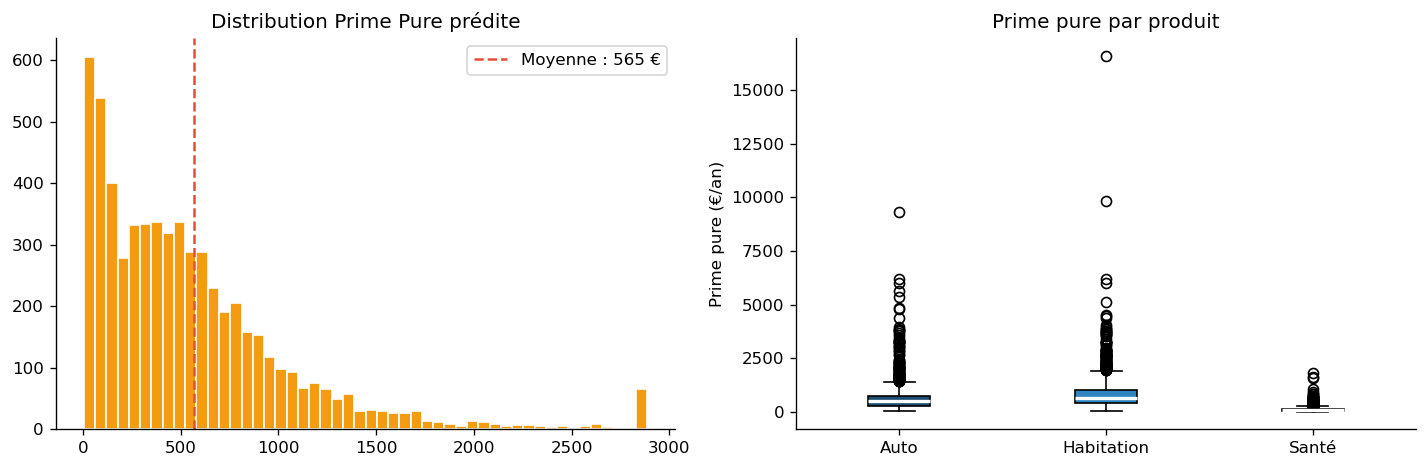

In [6]:
X_all = df[FEATURE_COLS].fillna(0)
freq_all = xgb_freq.predict(X_all)
sev_all  = xgb_sev.predict(X_all)
pp_all   = freq_all * sev_all

df["freq_pred"]         = freq_all
df["sev_pred"]          = sev_all
df["pure_premium_pred"] = pp_all
df.to_csv("data/features/table_scores.csv", index=False)

print(f"Prime pure moyenne  : {pp_all.mean():,.0f} €/police/an")
print(f"Prime pure médiane  : {np.median(pp_all):,.0f} €/police/an")
print(f"Percentile 90       : {np.percentile(pp_all, 90):,.0f} €")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(np.clip(pp_all, 0, np.percentile(pp_all,99)), bins=50,
             color="#F39C12", edgecolor="white")
axes[0].axvline(pp_all.mean(), color="#E74C3C", linestyle="--",
                label=f"Moyenne : {pp_all.mean():,.0f} €")
axes[0].set_title("Distribution Prime Pure prédite"); axes[0].legend()

produit_cols = [c for c in df.columns if c.startswith("type_produit_")]
df["produit"] = df[produit_cols].idxmax(axis=1).str.replace("type_produit_","")
data_bp = [df[df["produit"]==p]["pure_premium_pred"].values for p in ["Auto","Habitation","Santé"]]
bp = axes[1].boxplot(data_bp, patch_artist=True, labels=["Auto","Habitation","Santé"],
                     medianprops={"color":"white","linewidth":2})
for patch, color in zip(bp["boxes"], ["#1B4F72","#2E86C1","#F39C12"]):
    patch.set_facecolor(color)
axes[1].set_title("Prime pure par produit"); axes[1].set_ylabel("Prime pure (€/an)")

plt.tight_layout(); plt.show()
with open("models/feature_cols.pkl","wb") as f: pickle.dump(FEATURE_COLS,f)

## 6. Explicabilité SHAP

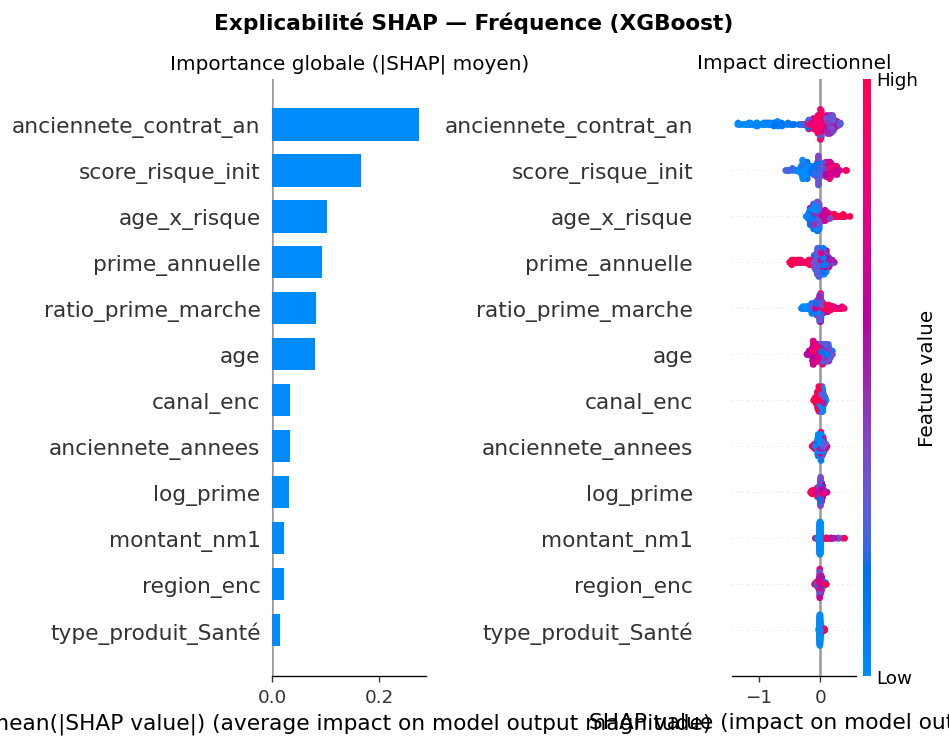


✅ Modélisation terminée — 4 modèles sauvegardés dans models/


In [7]:
explainer   = shap.TreeExplainer(xgb_freq)
shap_values = explainer.shap_values(X_test.iloc[:300])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Explicabilité SHAP — Fréquence (XGBoost)", fontsize=13, fontweight="bold")

plt.sca(axes[0])
shap.summary_plot(shap_values, X_test.iloc[:300], plot_type="bar",
                  feature_names=FEATURE_COLS, show=False, max_display=12)
axes[0].set_title("Importance globale (|SHAP| moyen)")

plt.sca(axes[1])
shap.summary_plot(shap_values, X_test.iloc[:300],
                  feature_names=FEATURE_COLS, show=False, max_display=12)
axes[1].set_title("Impact directionnel")

plt.tight_layout()
plt.savefig("reports/figures/07_shap_frequence.png", bbox_inches="tight")
plt.show()

print("\n✅ Modélisation terminée — 4 modèles sauvegardés dans models/")